# Lifting and Query

Features come per frame; lifting moves them onto the 3D scene. Each 3D point looks itself up in
every keyframe that sees it and averages those features. Afterwards you can search the mesh with
text. This page lifts Talk2DINO features by hand, then queries the mesh the `semantics` stage
lifted.

In [1]:
import numpy as np
import pyvista as pv
import torch
import transformers
import trimesh
import zarr

from collab_splats.pointcloud import PointcloudResult
from collab_splats.preproc.frames import frame_idx_from_path, frame_paths
from collab_splats.semantics import (
    FeatureAutoencoder,
    Talk2DinoExtractor,
    read_point_features,
    write_point_features,
)
from collab_splats.semantics.lifting import lift_features, transfer_features
from collab_splats.utils.torch_utils import batch_iterator
from collab_splats.utils.visualization import apply_view, camera_view

%run ../tutorial.py

# Hide a harmless checkpoint warning from Talk2DINO
transformers.logging.set_verbosity_error()

scene = tutorial_scene("preproc", "pointcloud", "mesh", "semantics")

## 1. Features per frame

Extract Talk2DINO features for every keyframe, in the point cloud's frame order:

In [2]:
# The point cloud with depth and confidence; lifting needs both
cloud = PointcloudResult.load_zarr(scene.pointcloud_zarr, load_world_points=False)
paths = frame_paths(scene.images_dir, [frame_idx_from_path(p) for p in cloud.image_paths])

extractor = Talk2DinoExtractor()
maps = []

for (batch,) in batch_iterator(4, paths):
    maps.extend(extractor.forward(batch))

stacked = torch.stack(maps)
print(f"{len(maps)} maps of {tuple(maps[0].shape)}, {stacked.nbytes / 2**30:.2f} GiB")

96 maps of (768, 32, 18), 0.16 GiB


## 2. Compressing

Storing a full feature vector per point is costly, so a small autoencoder learns to squeeze each
one into 64 numbers and back. The reconstruction cosine says how well it comes back: 1 is
perfect. It is measured on the training data, so read it as "the fit converged".

In [3]:
features = stacked.numpy()
ae = FeatureAutoencoder(input_dim=features.shape[1], latent_dim=64)
ae.fit(features, epochs=20, target_cosine=0.95)
print(f"reconstruction cosine {ae.recon_cosine:.3f} after {ae.epochs_run} epochs")

# Each frame's map as 64-D codes
ae.cpu()

with torch.no_grad():
    codes = [ae.encode(fmap) for fmap in maps]

reconstruction cosine 0.950 after 8 epochs


## 3. Lifting onto points

`lift_features` projects each point into every frame, keeps the frames whose depth agrees with
the point (so hidden points are skipped), and averages their codes. Saving writes the codes and
the autoencoder; reading decodes back to full features.

In [4]:
point_codes = lift_features(codes.__getitem__, cloud).numpy()

store_path = work_dir("lifting_and_query") / "talk2dino_lifted.zarr"
write_point_features(store_path, point_codes, ae)
point_features = read_point_features(store_path)
print(f"{len(point_features):,} points, {point_features.shape[1]}-D features")

500,000 points, 768-D features


## 4. Querying the mesh

The `semantics` stage did the same lift onto the vertices of `mesh.ply`. A vertex no frame sees
has no feature and is drawn grey below.

Load the stage's per-vertex features:

In [5]:
lifted = scene.lifted_stores["talk2dino"]
raw = np.asarray(zarr.open(str(lifted), mode="r")["vertex_features"])
observed = raw.any(axis=1)
vertex_features = torch.from_numpy(read_point_features(lifted, name="vertex_features"))
print(f"{observed.mean():.1%} of {len(observed):,} vertices observed")

98.9% of 335,017 vertices observed


Score two prompts on every vertex, as on the feature extraction page. `transfer_features` then
averages each vertex's score with its 8 nearest neighbors, which smooths noise and fills small
gaps.

In [6]:
NEGATIVES = ["object", "background", "ground", "sky"]
tree = extractor.score_queries(vertex_features, positive=["tree"], negative=NEGATIVES)
can = extractor.score_queries(vertex_features, positive=["trash can"], negative=NEGATIVES)
scores = np.stack([tree.cpu().numpy(), can.cpu().numpy()], axis=1)

# Smooth the observed scores over neighboring vertices; unreached vertices stay grey
mesh = trimesh.load(scene.outputs["mesh"], process=False)
vertices = np.asarray(mesh.vertices, dtype=np.float32)
smoothed = transfer_features(vertices, vertices[observed], scores[observed], k=8)
smoothed[~smoothed.any(axis=1)] = np.nan

"tree" and "trash can" on the mesh, seen from the side. Yellow matches the prompt; grey was never
seen:

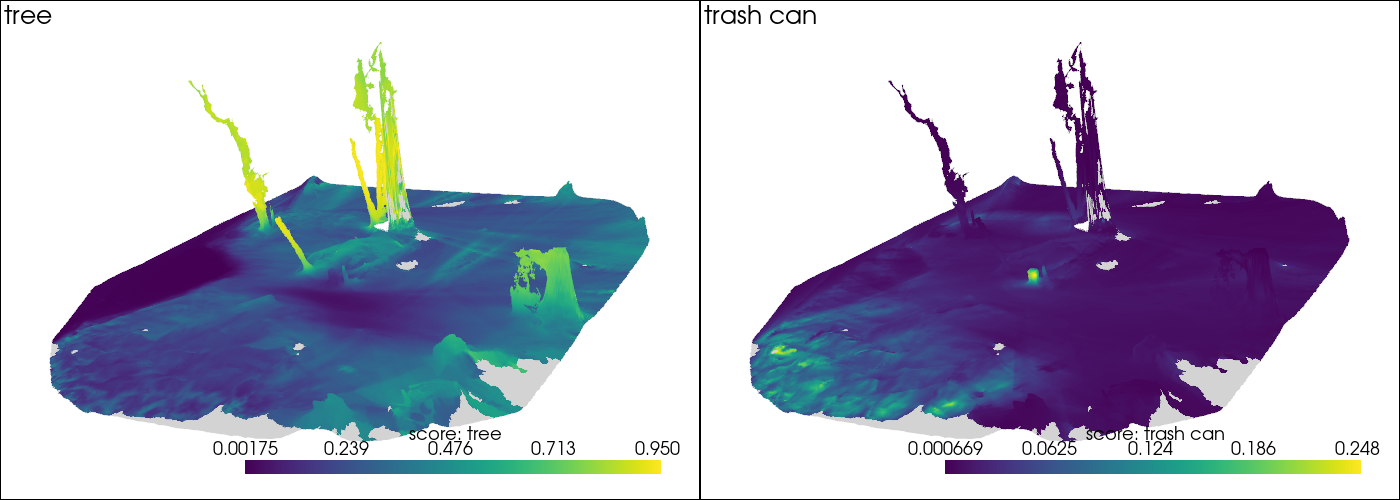

In [7]:
surface = pv.wrap(mesh)
plotter = pv.Plotter(shape=(1, 2), window_size=(1400, 500))

for col, (prompt, values) in enumerate([("tree", smoothed[:, 0]), ("trash can", smoothed[:, 1])]):
    plotter.subplot(0, col)
    plotter.add_text(prompt, font_size=10)
    plotter.add_mesh(
        surface.copy(),
        scalars=values,
        cmap="viridis",
        nan_color="lightgrey",
        lighting=False,
        scalar_bar_args={"title": f"score: {prompt}"},
    )

plotter.link_views()
apply_view(plotter, camera_view(cloud.extrinsics, vertices))
plotter.show()

The trunks should light up for "tree" while the ground stays dark. Each panel has its own color
range, so the trash can stands out even though its scores are lower.

## In a pipeline run

The `semantics` stage does all of the above for every keyframe and writes
`<backend>/semantics/talk2dino_lifted.zarr`. `max_epochs` caps the autoencoder fit.

```yaml
semantics:
  enabled: true
  extractors: [talk2dino]
  max_epochs: 20
```

To query interactively, open the scene in the viewer and pick the store from its Semantics menu:

```bash
python -m collab_splats.viewer data/tutorial_scene/vggt_omega --port 8080
```